In [ ]:
# Step 1 — install deps (first cell)
!pip install xgboost lightgbm catboost optuna shap --quiet

# Step 2 — upload your CSV
from google.colab import files
uploaded = files.upload()   # select Bengaluru_House_Data.csv

# Step 3 — run the script
exec(open("Bengaluru_House_Data.py").read())

Saving Bengaluru_House_Data.csv to Bengaluru_House_Data (1).csv


FileNotFoundError: [Errno 2] No such file or directory: 'Bengaluru_House_Data.py'

Shape: (13320, 9)
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  

Missing values:
 area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Dtyp

  0%|          | 0/60 [00:00<?, ?it/s]

  LightGBM (Optuna)               MAE=  26.01  RMSE=  60.71  R²=0.7329
  Best params: {'n_estimators': 310, 'learning_rate': 0.09274221695690235, 'max_depth': 7, 'num_leaves': 107, 'subsample': 0.8575709654612196, 'colsample_bytree': 0.5547809279932466, 'reg_alpha': 0.0054594491417304745, 'reg_lambda': 0.011091884927508636}

── Stacking Ensemble ──
  Stacking Ensemble               MAE=  24.07  RMSE=  53.23  R²=0.7947


══════════ FINAL LEADERBOARD ══════════
            Model       MAE      RMSE       R2
Stacking Ensemble 24.067597 53.226724 0.794711
    Random Forest 23.751986 54.116037 0.787794
         CatBoost 25.152022 54.946774 0.781229
          XGBoost 23.847060 58.320771 0.753536
LightGBM (Optuna) 26.006418 60.709132 0.732937
         LightGBM 26.360282 60.988776 0.730471

🏆  Best model: Stacking Ensemble


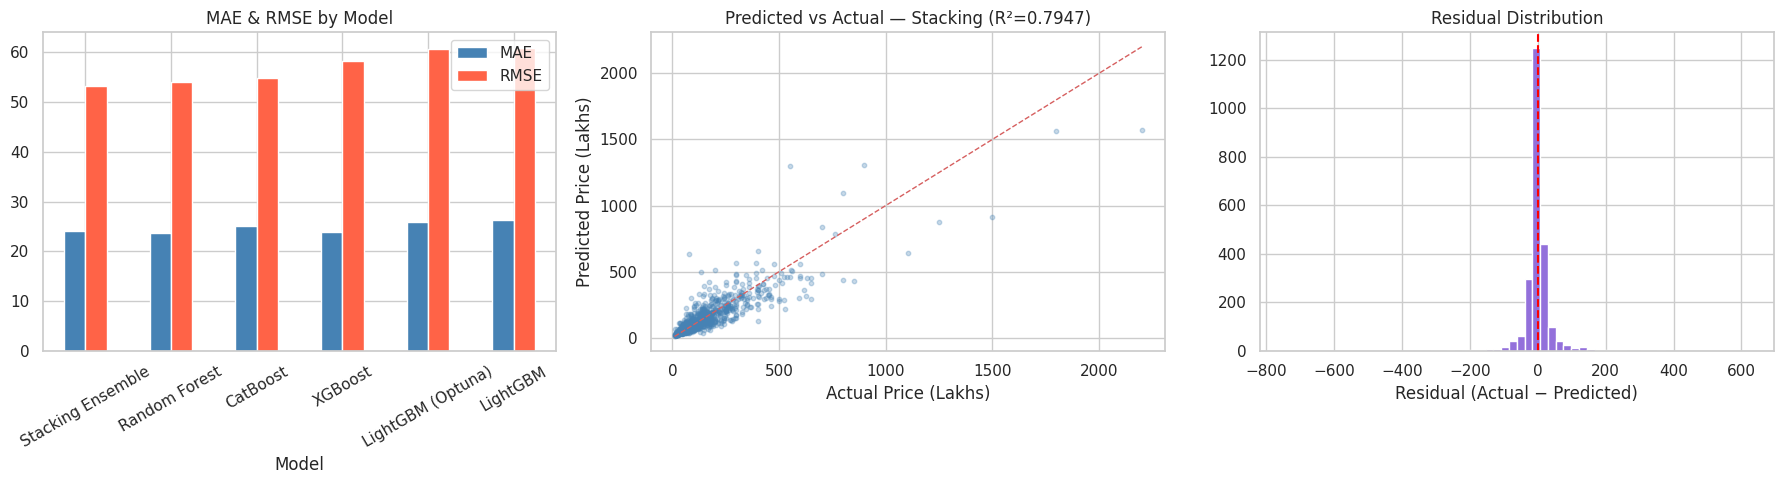


── SHAP Feature Importance ──


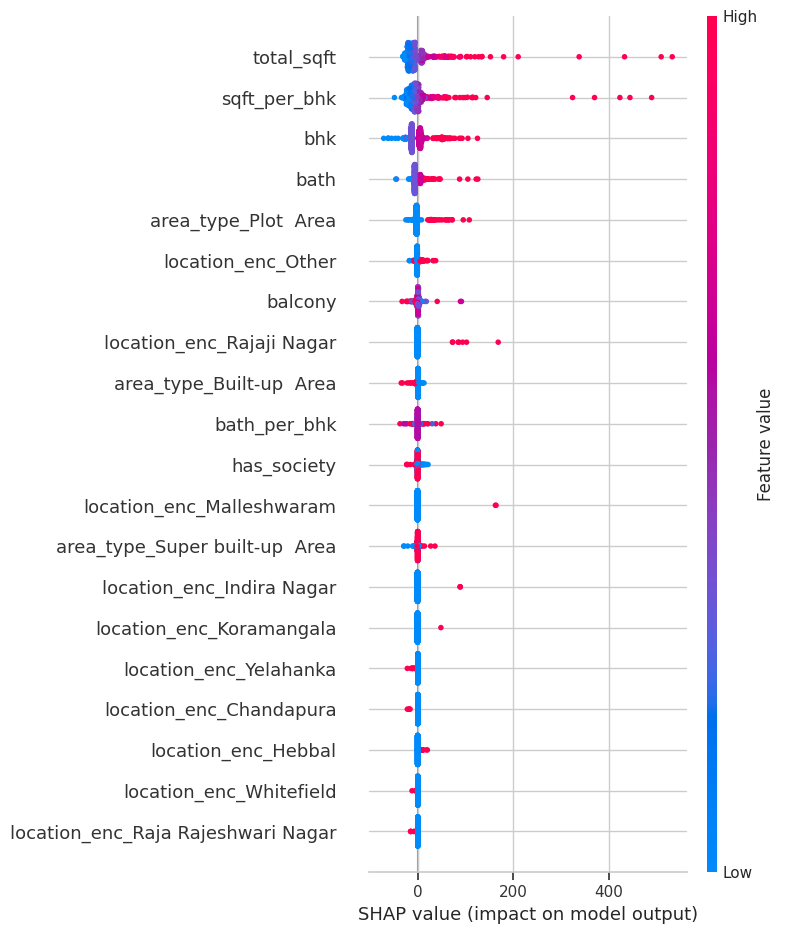


── Sample Predictions ──
  Whitefield                 2BHK/1200 sqft  →  ₹ 52.97 Lakhs
  Koramangala                4BHK/2500 sqft  →  ₹ 324.25 Lakhs
  Electronic City            1BHK/600 sqft  →  ₹ 33.59 Lakhs
  Jayanagar                  5BHK/3500 sqft  →  ₹ 357.9 Lakhs

✅  Done! Outputs saved → model_comparison.png, shap_importance.png


In [ ]:
# =============================================================================
# BENGALURU HOUSE PRICE PREDICTION — Google Colab Ready
# Dataset: Bengaluru_House_Data.csv  (~13,320 rows, 9 columns)
# Target : price (in Lakhs INR)
# Models : XGBoost · LightGBM · CatBoost · Random Forest · Stacking Ensemble
# =============================================================================

# ── 0. Install dependencies (run once in Colab) ─────────────────────────────
# !pip install xgboost lightgbm catboost optuna shap --quiet

# ── 1. Imports ───────────────────────────────────────────────────────────────
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.impute            import SimpleImputer
from sklearn.preprocessing    import OneHotEncoder
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model     import Ridge
from sklearn.metrics          import mean_absolute_error, mean_squared_error, r2_score

import xgboost  as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
SEED = 42

# ── 2. Load Data ─────────────────────────────────────────────────────────────
# ▶ Upload via Colab:
#   from google.colab import files
#   uploaded = files.upload()
#   df = pd.read_csv(next(iter(uploaded)))
# ▶ OR mount Drive:
#   from google.colab import drive
#   drive.mount('/content/drive')
#   df = pd.read_csv('/content/drive/MyDrive/Bengaluru_House_Data.csv')

df = pd.read_csv("Bengaluru_House_Data.csv")
print(f"Shape: {df.shape}")
print(df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nDtypes:\n", df.dtypes)

# ── 3. Feature Engineering ───────────────────────────────────────────────────

def parse_total_sqft(x):
    """Handle range strings like '1000-1200' → average; else cast to float."""
    x = str(x).strip()
    if "-" in x:
        parts = x.split("-")
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    try:
        return float(re.sub(r"[^\d.]", "", x))
    except ValueError:
        return np.nan

df["total_sqft"] = df["total_sqft"].apply(parse_total_sqft)

def extract_bhk(size):
    """'3 BHK' → 3, '4 Bedroom' → 4"""
    if pd.isnull(size):
        return np.nan
    m = re.search(r"(\d+)", str(size))
    return int(m.group(1)) if m else np.nan

df["bhk"] = df["size"].apply(extract_bhk)

# Derived features
df["price_per_sqft"] = df["price"] / df["total_sqft"]          # target leakage guard later
df["bath_per_bhk"]   = df["bath"] / df["bhk"].replace(0, np.nan)
df["sqft_per_bhk"]   = df["total_sqft"] / df["bhk"].replace(0, np.nan)
df["has_society"]    = df["society"].notna().astype(int)

# Normalise area_type
df["area_type"] = df["area_type"].str.strip()

# Location frequency encoding (high-cardinality column)
loc_freq = df["location"].str.strip().value_counts()
df["location_clean"] = df["location"].str.strip()
# Keep top-N locations; group rest as "Other"
TOP_N = 150
top_locs = loc_freq[loc_freq >= 10].index
df["location_enc"] = df["location_clean"].apply(lambda x: x if x in top_locs else "Other")

# ── 4. Outlier Removal ───────────────────────────────────────────────────────
# Rule 1: sqft per BHK should be ≥ 300
df = df[df["sqft_per_bhk"].fillna(300) >= 300]
# Rule 2: price_per_sqft within 3 IQR of mean per location
def remove_pps_outliers(data):
    out = []
    for loc, grp in data.groupby("location_enc"):
        m, s = grp["price_per_sqft"].mean(), grp["price_per_sqft"].std()
        out.append(grp[(grp["price_per_sqft"] > m - 3*s) & (grp["price_per_sqft"] < m + 3*s)])
    return pd.concat(out)

df = remove_pps_outliers(df)
print(f"\nShape after outlier removal: {df.shape}")

# ── 5. Define Final Features & Target ────────────────────────────────────────
NUM_FEATS = ["total_sqft", "bhk", "bath", "balcony",
             "bath_per_bhk", "sqft_per_bhk", "has_society"]
CAT_FEATS = ["area_type", "location_enc"]

TARGET = "price"

# Drop rows where any NUM_FEATS has NaN
df_model = df[NUM_FEATS + CAT_FEATS + [TARGET]].copy()
df_model[NUM_FEATS] = df_model[NUM_FEATS].apply(pd.to_numeric, errors="coerce")
df_model.dropna(subset=NUM_FEATS + [TARGET], inplace=True)
df_model[CAT_FEATS] = df_model[CAT_FEATS].fillna("Unknown")

X = df_model[NUM_FEATS + CAT_FEATS]
y = df_model[TARGET]
print(f"\nFinal modelling shape  X:{X.shape}  y:{y.shape}")

# ── 6. Preprocessing Pipeline ────────────────────────────────────────────────
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, NUM_FEATS),
    ("cat", cat_transformer, CAT_FEATS),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

# ── 7. Baseline Models ───────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<30}  MAE={mae:7.2f}  RMSE={rmse:7.2f}  R²={r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_train_t, y_train)
results.append(evaluate("Random Forest", y_test, rf.predict(X_test_t)))

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train_t, y_train,
              eval_set=[(X_test_t, y_test)],
              verbose=False)
results.append(evaluate("XGBoost", y_test, xgb_model.predict(X_test_t)))

# LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train_t, y_train,
              eval_set=[(X_test_t, y_test)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
results.append(evaluate("LightGBM", y_test, lgb_model.predict(X_test_t)))

# CatBoost (handles categoricals natively — here we use preprocessed features)
cb_model = CatBoostRegressor(
    iterations=600, learning_rate=0.05, depth=6,
    random_seed=SEED, verbose=0
)
cb_model.fit(X_train_t, y_train,
             eval_set=(X_test_t, y_test),
             early_stopping_rounds=50)
results.append(evaluate("CatBoost", y_test, cb_model.predict(X_test_t)))

# ── 8. Optuna Hyperparameter Tuning (LightGBM) ───────────────────────────────
print("\n── Optuna HPO for LightGBM (60 trials) ──")

def objective(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators",  300, 1000),
        "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth":       trial.suggest_int("max_depth", 4, 10),
        "num_leaves":      trial.suggest_int("num_leaves", 20, 150),
        "subsample":       trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state": SEED, "n_jobs": -1, "verbose": -1,
    }
    model = lgb.LGBMRegressor(**params)
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(model, X_train_t, y_train,
                             cv=cv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=60, show_progress_bar=True)

best_lgb = lgb.LGBMRegressor(**study.best_params, random_state=SEED,
                               n_jobs=-1, verbose=-1)
best_lgb.fit(X_train_t, y_train)
results.append(evaluate("LightGBM (Optuna)", y_test, best_lgb.predict(X_test_t)))
print(f"  Best params: {study.best_params}")

# ── 9. Stacking Ensemble ─────────────────────────────────────────────────────
print("\n── Stacking Ensemble ──")

estimators = [
    ("rf",  RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)),
    ("xgb", xgb.XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                               random_state=SEED, verbosity=0, n_jobs=-1)),
    ("lgb", best_lgb),
    ("cb",  CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6,
                               random_seed=SEED, verbose=0)),
]
meta = Ridge()
stack = StackingRegressor(estimators=estimators, final_estimator=meta,
                          cv=5, n_jobs=-1)
stack.fit(X_train_t, y_train)
results.append(evaluate("Stacking Ensemble", y_test, stack.predict(X_test_t)))

# ── 10. Results Summary ───────────────────────────────────────────────────────
print("\n\n══════════ FINAL LEADERBOARD ══════════")
res_df = pd.DataFrame(results).sort_values("RMSE")
print(res_df.to_string(index=False))

best_model_name = res_df.iloc[0]["Model"]
print(f"\n🏆  Best model: {best_model_name}")

# ── 11. Visualisations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 11a  Model comparison bar chart
res_df_plot = res_df.set_index("Model")
res_df_plot[["MAE", "RMSE"]].plot(kind="bar", ax=axes[0], color=["steelblue","tomato"])
axes[0].set_title("MAE & RMSE by Model")
axes[0].tick_params(axis="x", rotation=30)

# 11b  Predicted vs Actual (best model = stacking)
best_preds = stack.predict(X_test_t)
axes[1].scatter(y_test, best_preds, alpha=0.3, s=10, color="steelblue")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[1].plot(lims, lims, "r--", lw=1)
axes[1].set_xlabel("Actual Price (Lakhs)")
axes[1].set_ylabel("Predicted Price (Lakhs)")
axes[1].set_title(f"Predicted vs Actual — Stacking (R²={r2_score(y_test,best_preds):.4f})")

# 11c  Residual distribution
residuals = y_test.values - best_preds
axes[2].hist(residuals, bins=60, color="mediumpurple", edgecolor="white")
axes[2].axvline(0, color="red", linestyle="--")
axes[2].set_xlabel("Residual (Actual − Predicted)")
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

# ── 12. SHAP Feature Importance (LightGBM best) ──────────────────────────────
print("\n── SHAP Feature Importance ──")

explainer = shap.TreeExplainer(best_lgb)
shap_vals  = explainer.shap_values(X_test_t[:500])   # sample for speed

# Get feature names after OHE
ohe_features = (preprocessor
                .named_transformers_["cat"]["ohe"]
                .get_feature_names_out(CAT_FEATS).tolist())
feature_names = NUM_FEATS + ohe_features

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test_t[:500], feature_names=feature_names,
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150)
plt.show()

# ── 13. Inference Function ────────────────────────────────────────────────────

def predict_price(
    total_sqft, bhk, bath, balcony,
    area_type="Super built-up  Area",
    location="Whitefield"
):
    """
    Predict house price in Lakhs INR.

    Parameters
    ----------
    total_sqft  : float  – carpet/built-up area in sq ft
    bhk         : int    – number of bedrooms
    bath        : int    – number of bathrooms
    balcony     : int    – number of balconies
    area_type   : str    – 'Super built-up  Area' | 'Built-up  Area' |
                           'Carpet  Area' | 'Plot  Area'
    location    : str    – locality name (use 'Other' if unknown)

    Returns
    -------
    float  – predicted price in Lakhs
    """
    loc_enc = location if location in top_locs else "Other"
    bath_per_bhk = bath / max(bhk, 1)
    sqft_per_bhk = total_sqft / max(bhk, 1)
    has_society  = 0   # unknown at inference time

    sample = pd.DataFrame([{
        "total_sqft":   total_sqft,
        "bhk":          bhk,
        "bath":         bath,
        "balcony":      balcony,
        "bath_per_bhk": bath_per_bhk,
        "sqft_per_bhk": sqft_per_bhk,
        "has_society":  has_society,
        "area_type":    area_type,
        "location_enc": loc_enc,
    }])

    X_inp = preprocessor.transform(sample)
    price = stack.predict(X_inp)[0]
    return round(price, 2)

# ── Example predictions ───────────────────────────────────────────────────────
print("\n── Sample Predictions ──")
test_cases = [
    (1200, 2, 2, 1, "Super built-up  Area", "Whitefield"),
    (2500, 4, 4, 2, "Built-up  Area",       "Koramangala"),
    (600,  1, 1, 0, "Carpet  Area",         "Electronic City"),
    (3500, 5, 5, 3, "Plot  Area",           "Jayanagar"),
]
for tc in test_cases:
    p = predict_price(*tc)
    print(f"  {tc[5]:<25}  {tc[2]}BHK/{tc[0]} sqft  →  ₹ {p} Lakhs")

print("\n✅  Done! Outputs saved → model_comparison.png, shap_importance.png")